In [1]:
import wandb
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.pyplot import cm
import re
import math
import matplotlib.gridspec as gridspec
import json
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

api = wandb.Api(timeout=19)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mila/r/roy.eyono/.netrc.


In [2]:
# Fetch runs for a specific project
def fetch_runs(api, entity, project_name, filters, order=None):
    if order:
        runs = api.runs(f"{entity}/{project_name}", filters=filters, order=order, lazy=False)
    else:
        runs = api.runs(f"{entity}/{project_name}", filters=filters, lazy=False)
    #print(f"Runs for project '{project_name}':")
    return runs

In [3]:
def same_config(config1, config2, keys=['normtype']):
    for key in keys:
        if config1[key] != config2[key]:
            return False
    return True

Points plotted: 121


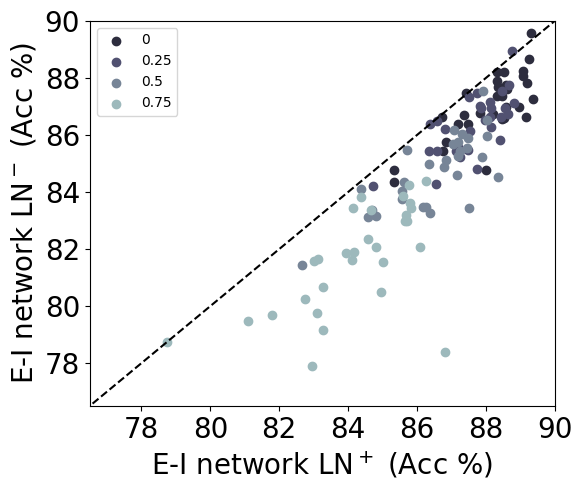

In [4]:
fig, ax = plt.subplots(figsize=(6,5))

# Example brightness factors used
brightness_values = [0, 0.25, 0.5, 0.75]

# Normalize brightness for colormap mapping
norm = mcolors.Normalize(vmin=min(brightness_values), vmax=max(brightness_values))

def truncate_colormap(cmap, minval=0.2, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Create a grayscale colormap from 20% (dark gray) to 100% (black)
cmap = truncate_colormap(plt.get_cmap('bone'), 0.2, 0.7)

scatter_handles = []  # For legend proxy if needed
list_line = range(100)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.plot(list_line, list_line, color='black', linestyle='--')
ax.set_xlabel(f"E-I network LN$^+$ (Acc %)", fontsize=20)
ax.set_ylabel("E-I network LN$^-$ (Acc %)", fontsize=20)

count = 0

for bfi in brightness_values:
    color = cmap(norm(bfi))

    runs_dict = dict()

    runs_dict["runs_ei_network_noln"] = fetch_runs(api, entity='royeyono', project_name='Luminosity_LNHomeostasis', filters={"config.dataset": "fashionmnist", 
                                                            "config.brightness_factor": bfi, "config.homeostasis": 0, "config.normtype": 0, "config.normtype_detach": 0,
                                                            "config.excitation_training": 0, "config.layer_norm": 0, "config.use_testset": True}, order="-summary_metrics.test_acc")

    runs_dict["runs_ei_network_ln"] = fetch_runs(api, entity='royeyono', project_name='Luminosity_LNHomeostasis', filters={"config.dataset": "fashionmnist", 
                                                            "config.brightness_factor": bfi, "config.homeostasis": 0, "config.normtype": 0, "config.normtype_detach": 0,
                                                            "config.excitation_training": 0, "config.layer_norm": 1, "config.use_testset": True}, order="-summary_metrics.test_acc")

    top_n = len(runs_dict["runs_ei_network_noln"])

    for top in range(top_n):
        vanilla_dann_acc = runs_dict["runs_ei_network_noln"][top].summary['test_acc']
        for rn in runs_dict["runs_ei_network_ln"]:
            if same_config(rn.config, runs_dict["runs_ei_network_noln"][top].config, keys=['lr', 'wd','inhib_lrs', 'momentum', 'inhib_momentum']):
                sc = ax.scatter(rn.summary['test_acc'], vanilla_dann_acc, color=color, label=f"{bfi}" if top == 0 else None)
                count+=1
                break  # Only label once per brightness group
print(f"Points plotted: {count}")
ax.set_xlim(76.5, 90)
ax.set_ylim(76.5, 90)
# ax.set_xlim(82, 91)
# ax.set_ylim(82, 91)
ax.legend(loc='upper left')

Mann–Whitney U p-value: 0.8966340961332189


/tmp/ipykernel_960352/1986185004.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


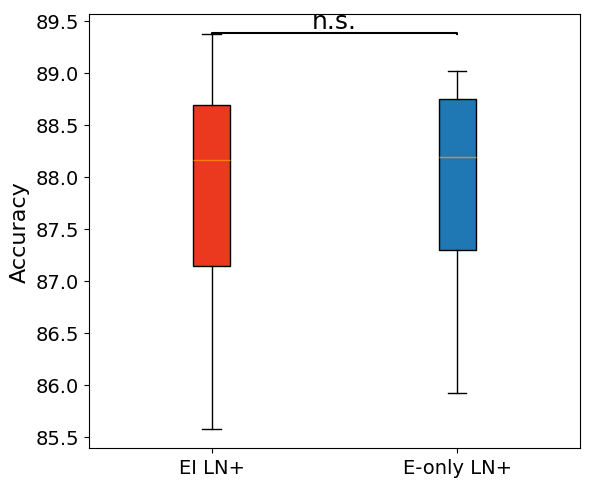

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ---------------------------------------
# Collect values across luminosity levels
# ---------------------------------------

brightness_factor = [0, 0.25, 0.5, 0.75]
best_n_runs = 10

ln_vals_all = []      # EI LN+
e_ln_vals_all = []    # E-only LN+

for bf in brightness_factor:

    layernorm_ei_network = fetch_runs(
        api, entity='royeyono', project_name='Luminosity_LNHomeostasis',
        filters={
            "config.dataset": "fashionmnist",
            "config.brightness_factor": bf,
            "config.layer_norm": 1,
            "config.excitation_training": 0,
            "config.normtype_detach": 0,
            "config.use_testset": True,
            "config.homeostasis": 0
        },
        order="-summary_metrics.test_acc"
    )[:best_n_runs]

    layernorm_e_network = fetch_runs(
        api, entity='royeyono', project_name='Luminosity_LNHomeostasis',
        filters={
            "config.dataset": "fashionmnist",
            "config.brightness_factor": bf,
            "config.homeostasis": 0,
            "config.normtype": 0,
            "config.normtype_detach": 0,
            "config.excitation_training": 1,
            "config.layer_norm": 1,
            "config.use_testset": True
        },
        order="-summary_metrics.test_acc"
    )[:best_n_runs]

    ln_vals_all.extend([run.summary["test_acc"] for run in layernorm_ei_network])
    e_ln_vals_all.extend([run.summary["test_acc"] for run in layernorm_e_network])


# ---------------------------------------
# Statistical Test
# ---------------------------------------

stat, p = mannwhitneyu(ln_vals_all, e_ln_vals_all, alternative="two-sided")
print("Mann–Whitney U p-value:", p)

# Stars
if p < 0.001:
    stars = "***"
elif p < 0.01:
    stars = "**"
elif p < 0.05:
    stars = "*"
else:
    stars = "n.s."


# ---------------------------------------
# Boxplot
# ---------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))

box = ax.boxplot(
    [ln_vals_all, e_ln_vals_all],
    labels=["EI LN+", "E-only LN+"],
    patch_artist=True
)

# Colors
box['boxes'][0].set(facecolor="#eb3920")   # red-ish
box['boxes'][1].set(facecolor="#1f77b4")   # blue-ish

# ---------------------------------------
# Significance bar
# ---------------------------------------

y_max = max(max(ln_vals_all), max(e_ln_vals_all))
h = 0.01  # height of the bar

x1, x2 = 1, 2

ax.plot([x1, x1, x2, x2], [y_max, y_max + h, y_max + h, y_max], lw=1.5, c='black')
ax.text((x1 + x2) * 0.5, y_max + h * 1.1, stars, ha='center', va='bottom', fontsize=18)

# ---------------------------------------

ax.set_ylabel("Accuracy", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()

plt.show()


## Accuracy under brightness and contrast perturbations

The two left panels compare matched E–I network runs with and without layer normalization. The right panel shows the mean test accuracy of the top 10 runs at each perturbation strength; error bars denote ±1 standard deviation.

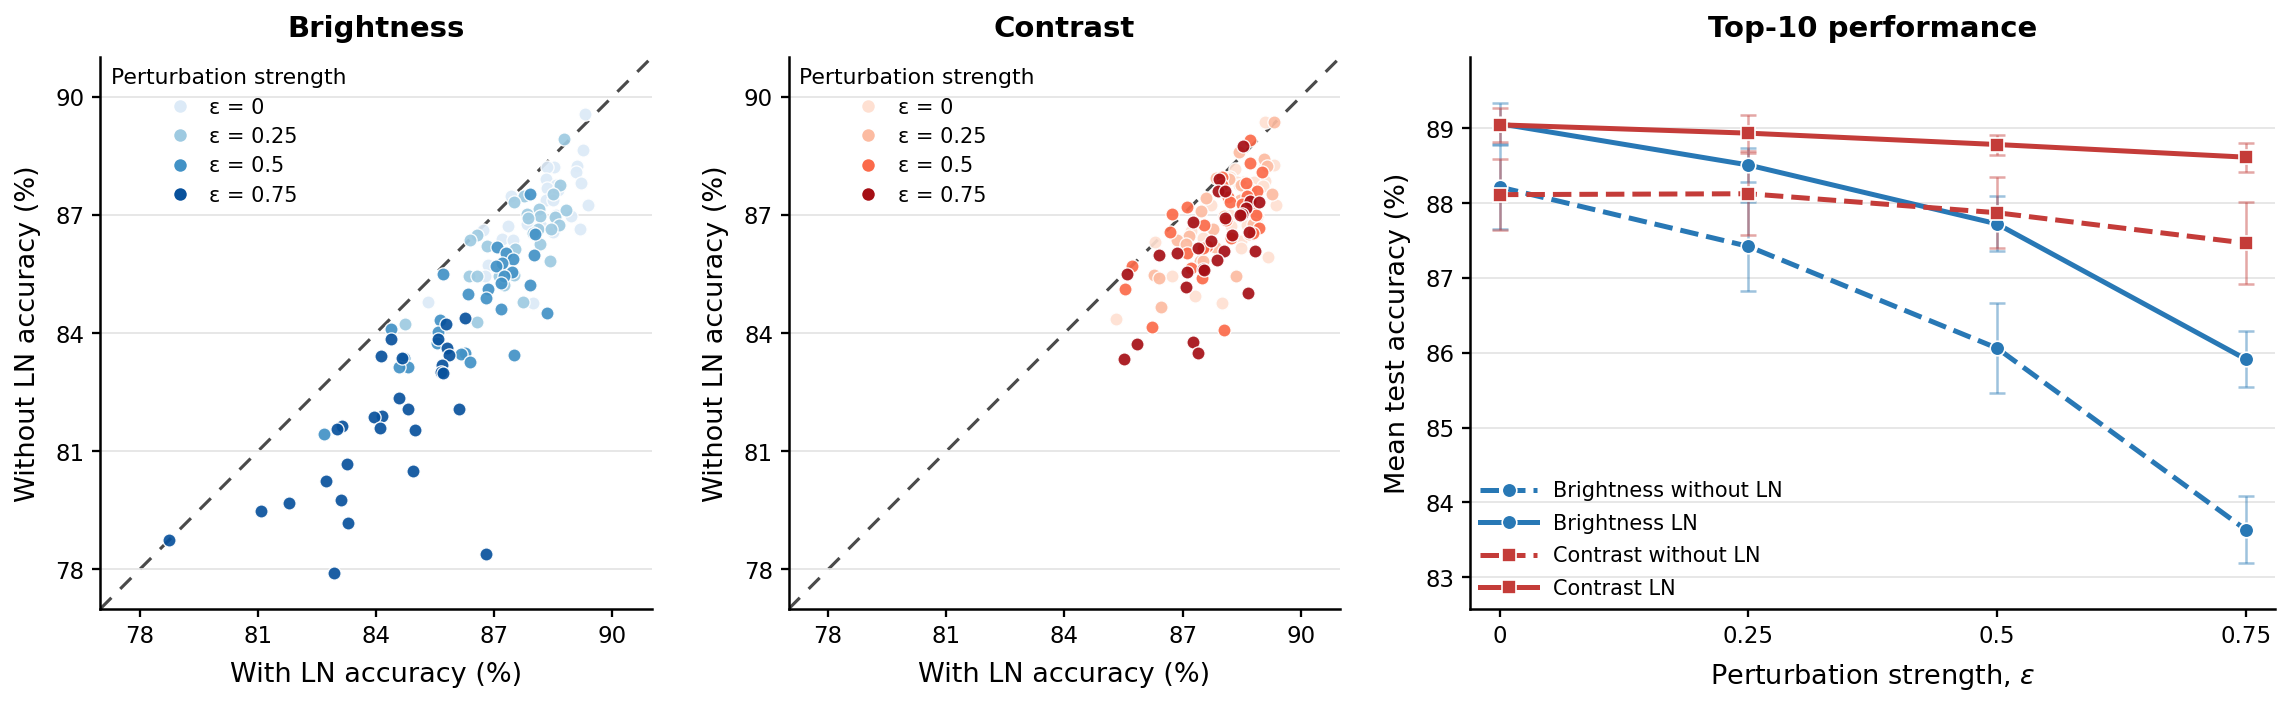

High-resolution PNG saved to: /home/mila/r/roy.eyono/RNN_EI_Network/experiments/dense_fmnist/analysis/fig_2_summary_highres.png
Brightness without LN: n = [10, 10, 10, 10]
Brightness LN: n = [10, 10, 10, 10]
Contrast without LN: n = [10, 10, 10, 10]
  Contrast LN: n = [10, 10, 10, 10]


In [6]:
# Clean summary figure: matched-run scatter plots + top-10 accuracy curves
from collections import defaultdict
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

EPSILONS = np.array([0.0, 0.25, 0.5, 0.75])
TOP_K = 10
PROJECT = "Luminosity_LNHomeostasis"
DATASETS = {
    "Brightness": "fashionmnist",
    "Contrast": "fashionmnist_contrast",
}
MATCH_KEYS = ("lr", "wd", "inhib_lrs", "momentum", "inhib_momentum")


def _get_runs(dataset, epsilon, layer_norm):
    """Fetch E–I runs for one perturbation strength, best accuracy first."""
    return list(fetch_runs(
        api,
        entity="royeyono",
        project_name=PROJECT,
        filters={
            "config.dataset": dataset,
            "config.brightness_factor": float(epsilon),
            "config.homeostasis": 0,
            "config.normtype": 0,
            "config.normtype_detach": 0,
            "config.excitation_training": 0,
            "config.layer_norm": int(layer_norm),
            "config.use_testset": True,
        },
        order="-summary_metrics.test_acc",
    ))


def _valid_accuracy(run):
    value = run.summary.get("test_acc")
    return value is not None and np.isfinite(value)


def _freeze_config_value(value):
    """Recursively convert nested W&B config values into hashable objects."""
    if isinstance(value, dict):
        return tuple(sorted(
            (key, _freeze_config_value(item)) for key, item in value.items()
        ))
    if isinstance(value, (list, tuple)):
        return tuple(_freeze_config_value(item) for item in value)
    if isinstance(value, set):
        return tuple(sorted(_freeze_config_value(item) for item in value))
    try:
        hash(value)
        return value
    except TypeError:
        if hasattr(value, "tolist"):
            return _freeze_config_value(value.tolist())
        return repr(value)


def _config_key(run):
    return tuple(
        _freeze_config_value(run.config.get(key)) for key in MATCH_KEYS
    )


def _match_accuracies(no_ln_runs, ln_runs):
    """Match runs one-to-one within each shared optimization configuration."""
    ln_by_config = defaultdict(list)
    for run in ln_runs:
        if _valid_accuracy(run):
            ln_by_config[_config_key(run)].append(run)

    pairs = []
    for run in no_ln_runs:
        matches = ln_by_config[_config_key(run)]
        if _valid_accuracy(run) and matches:
            ln_run = matches.pop(0)
            pairs.append((ln_run.summary["test_acc"], run.summary["test_acc"]))
    return np.asarray(pairs, dtype=float)


# Fetch once and reuse in all three panels.
runs = {}
for condition, dataset in DATASETS.items():
    for epsilon in EPSILONS:
        for layer_norm in (0, 1):
            runs[condition, epsilon, layer_norm] = _get_runs(
                dataset, epsilon, layer_norm
            )

paired = {
    (condition, epsilon): _match_accuracies(
        runs[condition, epsilon, 0], runs[condition, epsilon, 1]
    )
    for condition in DATASETS
    for epsilon in EPSILONS
}

# Show LN and no-LN performance on both evaluation streams.
curve_specs = {
    "Brightness without LN": ("Brightness", 0),
    "Brightness LN": ("Brightness", 1),
    "Contrast without LN": ("Contrast", 0),
    "Contrast LN": ("Contrast", 1),
}
curve_data = {}
for label, (condition, layer_norm) in curve_specs.items():
    means, stds, counts = [], [], []
    for epsilon in EPSILONS:
        valid_runs = [
            run for run in runs[condition, epsilon, layer_norm]
            if _valid_accuracy(run)
        ][:TOP_K]
        values = np.asarray([
            run.summary["test_acc"] for run in valid_runs
        ], dtype=float)
        means.append(values.mean() if values.size else np.nan)
        stds.append(values.std(ddof=1) if values.size > 1 else 0.0)
        counts.append(values.size)
    curve_data[label] = (np.asarray(means), np.asarray(stds), counts)

# Highly legible publication-style defaults, scoped to this figure only.
with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
}):
    fig, axes = plt.subplots(
        1, 3, figsize=(15.2, 4.6),
        gridspec_kw={"width_ratios": [1, 1, 1.32]},
        constrained_layout=True,
    )

    scatter_palettes = {
        "Brightness": ["#dceaf7", "#9ecae1", "#4292c6", "#08519c"],
        "Contrast": ["#fee0d2", "#fcbba1", "#fb6a4a", "#a50f15"],
    }

    # Use one shared range for both scatter plots and for both axes.
    all_scatter_points = [points for points in paired.values() if points.size]
    if all_scatter_points:
        stacked_points = np.vstack(all_scatter_points)
        scatter_lo = np.floor(stacked_points.min() - 0.6)
        scatter_hi = np.ceil(stacked_points.max() + 0.6)
    else:
        scatter_lo, scatter_hi = 0.0, 1.0

    # Matched-run scatter panels.
    for ax, condition in zip(axes[:2], ("Brightness", "Contrast")):
        for epsilon, color in zip(EPSILONS, scatter_palettes[condition]):
            points = paired[condition, epsilon]
            if points.size:
                ax.scatter(
                    points[:, 0], points[:, 1],
                    s=40, color=color, edgecolor="white", linewidth=0.65,
                    alpha=0.92, zorder=3,
                )

        ax.plot(
            [scatter_lo, scatter_hi], [scatter_lo, scatter_hi],
            ls=(0, (5, 4)), lw=1.5, color="#4a4a4a", zorder=1,
        )
        ax.set(xlim=(scatter_lo, scatter_hi), ylim=(scatter_lo, scatter_hi))
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(condition, pad=10)
        ax.set_xlabel("With LN accuracy (%)", labelpad=7)
        ax.set_ylabel("Without LN accuracy (%)", labelpad=7)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", color="#e3e3e3", linewidth=0.8, zorder=0)
        ax.tick_params(direction="out")

        handles = [
            Line2D([0], [0], marker="o", linestyle="none", markersize=7,
                   markerfacecolor=color, markeredgecolor="white",
                   label=f"ε = {epsilon:g}")
            for epsilon, color in zip(EPSILONS, scatter_palettes[condition])
        ]
        legend = ax.legend(
            handles=handles, title="Perturbation strength",
            frameon=False, handletextpad=0.4, labelspacing=0.45,
            borderpad=0, loc="upper left",
            prop={"family": "DejaVu Sans", "size": 10},
        )
        legend.get_title().set_fontfamily("DejaVu Sans")
        legend.get_title().set_fontsize(10.5)

    # Top-10 mean ± standard deviation panel.
    # Color identifies the task; line style identifies LN status.
    ax = axes[2]
    line_styles = {
        "Brightness without LN": ("#2878b5", "o", "--"),
        "Brightness LN": ("#2878b5", "o", "-"),
        "Contrast without LN": ("#c43c39", "s", "--"),
        "Contrast LN": ("#c43c39", "s", "-"),
    }
    for label, (color, marker, linestyle) in line_styles.items():
        mean, std, _ = curve_data[label]
        # Keep variability visible but visually subordinate to the mean curve.
        ax.errorbar(
            EPSILONS, mean, yerr=std, fmt="none",
            ecolor=mcolors.to_rgba(color, 0.45),
            elinewidth=1.2, capsize=4, capthick=1.2, zorder=2,
        )
        ax.plot(
            EPSILONS, mean, color=color, marker=marker, linestyle=linestyle,
            markersize=7, markeredgecolor="white", markeredgewidth=0.8,
            linewidth=2.4, label=label, zorder=3,
        )

    ax.set_title("Top-10 performance", pad=10)
    ax.set_xlabel(r"Perturbation strength, $\epsilon$", labelpad=7)
    ax.set_ylabel("Mean test accuracy (%)", labelpad=7)
    ax.set_xticks(EPSILONS)
    ax.set_xticklabels([f"{value:g}" for value in EPSILONS])
    ax.margins(x=0.04, y=0.10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e3e3e3", linewidth=0.8, zorder=0)
    ax.tick_params(direction="out")
    ax.legend(frameon=False, loc="best", handlelength=2.7,
              labelspacing=0.6, borderpad=0,
              prop={"family": "DejaVu Sans", "size": 10})

    output_path = Path("fig_2_summary_highres.png").resolve()
    # fig.savefig(
    #     output_path,
    #     dpi=600,
    #     bbox_inches="tight",
    #     pad_inches=0.08,
    #     facecolor="white",
    #     edgecolor="none",
    # )
    plt.show()

print(f"High-resolution PNG saved to: {output_path}")

# Quick data-availability check (each curve should normally show 10 runs per epsilon).
for label, (_, _, counts) in curve_data.items():
    print(f"{label:>13}: n = {counts}")

## E–I + LN versus E-only + LN

Each point is a pair of runs with matching optimization hyperparameters. Points above the identity line favor the E–I network; points below it favor the E-only network.

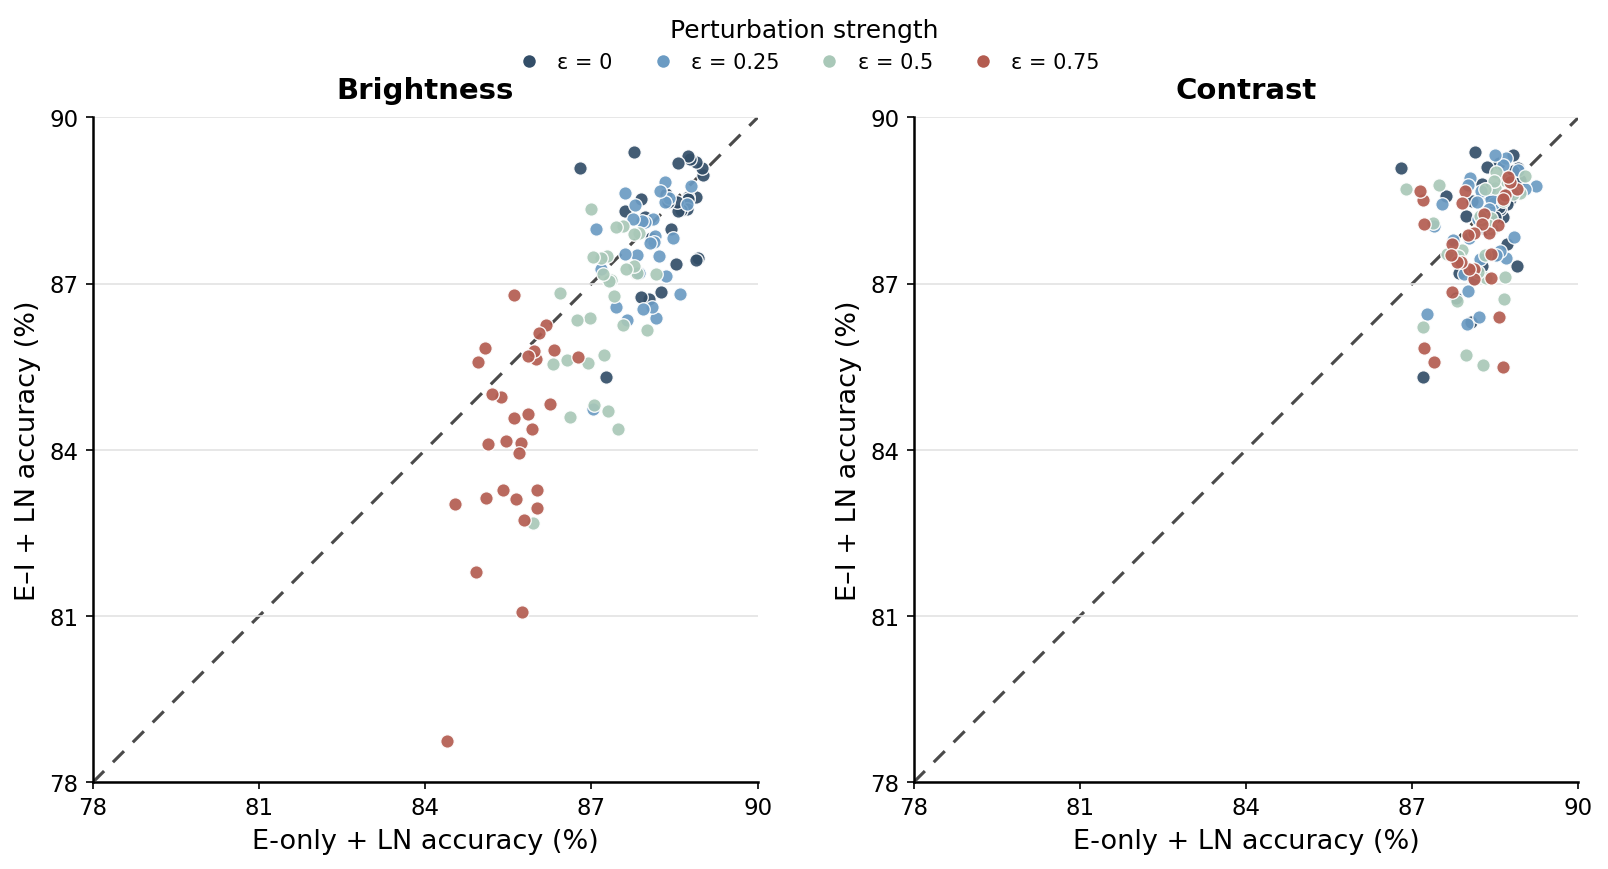

High-resolution PNG saved to: /home/mila/r/roy.eyono/RNN_EI_Network/experiments/dense_fmnist/analysis/fig_2_ei_vs_eonly_ln_highres.png
Brightness: matched n = [30, 30, 30, 30]
  Contrast: matched n = [30, 30, 30, 30]


In [8]:
# Paired architecture comparison: E–I + LN versus E-only + LN
ARCH_MATCH_KEYS = ("lr", "wd", "inhib_lrs", "momentum", "inhib_momentum")


def _freeze_arch_value(value):
    """Convert nested W&B config values into stable, hashable objects."""
    if isinstance(value, dict):
        return tuple(sorted(
            (key, _freeze_arch_value(item)) for key, item in value.items()
        ))
    if isinstance(value, (list, tuple)):
        return tuple(_freeze_arch_value(item) for item in value)
    if isinstance(value, set):
        return tuple(sorted(_freeze_arch_value(item) for item in value))
    try:
        hash(value)
        return value
    except TypeError:
        if hasattr(value, "tolist"):
            return _freeze_arch_value(value.tolist())
        return repr(value)


def _arch_config_key(run):
    return tuple(
        _freeze_arch_value(run.config.get(key)) for key in ARCH_MATCH_KEYS
    )


def _get_ln_arch_runs(dataset, epsilon, excitation_training):
    """Fetch LN+ runs for either the E–I or E-only architecture."""
    return list(fetch_runs(
        api,
        entity="royeyono",
        project_name=PROJECT,
        filters={
            "config.dataset": dataset,
            "config.brightness_factor": float(epsilon),
            "config.homeostasis": 0,
            "config.normtype": 0,
            "config.normtype_detach": 0,
            "config.excitation_training": int(excitation_training),
            "config.layer_norm": 1,
            "config.use_testset": True,
        },
        order="-summary_metrics.test_acc",
    ))


def _pair_architectures(e_only_runs, ei_runs):
    """Return [E-only accuracy, E–I accuracy] pairs for shared configs."""
    ei_by_config = defaultdict(list)
    for run in ei_runs:
        if _valid_accuracy(run):
            ei_by_config[_arch_config_key(run)].append(run)

    pairs = []
    for run in e_only_runs:
        matches = ei_by_config[_arch_config_key(run)]
        if _valid_accuracy(run) and matches:
            ei_run = matches.pop(0)
            pairs.append([
                run.summary["test_acc"],
                ei_run.summary["test_acc"],
            ])
    return np.asarray(pairs, dtype=float)


arch_pairs = {}
for condition, dataset in DATASETS.items():
    for epsilon in EPSILONS:
        e_only_runs = _get_ln_arch_runs(dataset, epsilon, excitation_training=1)
        ei_runs = _get_ln_arch_runs(dataset, epsilon, excitation_training=0)
        arch_pairs[condition, epsilon] = _pair_architectures(
            e_only_runs, ei_runs
        )

# One shared epsilon palette makes the two task panels directly comparable.
arch_colors = ["#334e68", "#6b9bc3", "#a9c8b8", "#b35c50"]

all_arch_points = [points for points in arch_pairs.values() if points.size]
if not all_arch_points:
    raise RuntimeError(
        "No matched E–I/E-only configurations were found. "
        "Check ARCH_MATCH_KEYS and the W&B filters."
    )
stacked_arch_points = np.vstack(all_arch_points)
arch_lo = np.floor(stacked_arch_points.min() - 0.6)
arch_hi = np.ceil(stacked_arch_points.max() + 0.6)

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}):
    # A compact 1.9:1 canvas closely matches two square panels side by side.
    fig, axes = plt.subplots(
        1, 2, figsize=(10.6, 5.6),
        constrained_layout=True,
    )
    fig.set_constrained_layout_pads(
        w_pad=0.04, h_pad=0.04, wspace=0.08, hspace=0.02
    )

    for ax, condition in zip(axes, ("Brightness", "Contrast")):
        for epsilon, color in zip(EPSILONS, arch_colors):
            points = arch_pairs[condition, epsilon]
            if points.size:
                ax.scatter(
                    points[:, 0], points[:, 1],
                    s=42, color=color, edgecolor="white", linewidth=0.65,
                    alpha=0.92, zorder=3,
                )

        ax.plot(
            [arch_lo, arch_hi], [arch_lo, arch_hi],
            color="#4a4a4a", linewidth=1.5, linestyle=(0, (5, 4)),
            zorder=1,
        )
        ax.set(
            xlim=(arch_lo, arch_hi), ylim=(arch_lo, arch_hi),
            xlabel="E-only + LN accuracy (%)",
            ylabel="E–I + LN accuracy (%)",
        )
        ax.set_title(condition, pad=9)
        ax.set_aspect("equal", adjustable="box")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        ax.tick_params(axis="y", which="both", labelleft=True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", color="#e3e3e3", linewidth=0.8, zorder=0)

    legend_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="none", markersize=7,
            markerfacecolor=color, markeredgecolor="white",
            label=f"ε = {epsilon:g}",
        )
        for epsilon, color in zip(EPSILONS, arch_colors)
    ]
    fig.legend(
        handles=legend_handles,
        title="Perturbation strength",
        loc="outside upper center", ncol=len(EPSILONS), frameon=False,
        handletextpad=0.35, columnspacing=1.4,
        prop={"family": "DejaVu Sans", "size": 10},
    )

    arch_output_path = Path("fig_2_ei_vs_eonly_ln_highres.png").resolve()
    # fig.savefig(
    #     arch_output_path,
    #     dpi=600,
    #     bbox_inches="tight",
    #     pad_inches=0.08,
    #     facecolor="white",
    #     edgecolor="none",
    # )
    plt.show()

print(f"High-resolution PNG saved to: {arch_output_path}")
for condition in DATASETS:
    counts = [len(arch_pairs[condition, epsilon]) for epsilon in EPSILONS]
    print(f"{condition:>10}: matched n = {counts}")

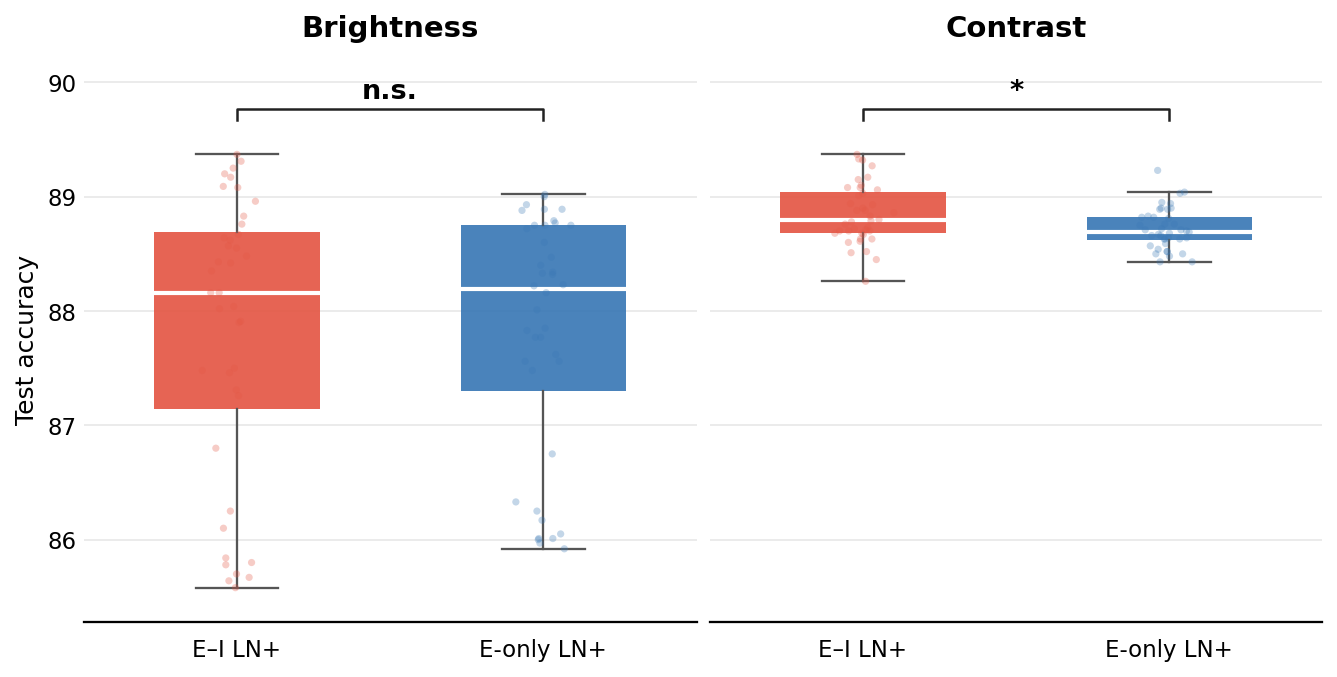

SVG plot saved to: /home/mila/r/roy.eyono/RNN_EI_Network/experiments/dense_fmnist/analysis/fig_2_ei_vs_eonly_ln_boxplots.svg
Brightness: n={'E–I LN+': 40, 'E-only LN+': 40}, Mann–Whitney p=0.897
Contrast: n={'E–I LN+': 40, 'E-only LN+': 40}, Mann–Whitney p=0.0186


In [12]:
# Sleek E–I LN+ vs E-only LN+ comparison for brightness and contrast
from pathlib import Path

TOP_K_ARCH = 10
ARCHITECTURE_COLORS = {"E–I LN+": "#E45745", "E-only LN+": "#3A78B5"}


def _top_accuracies(dataset, epsilon, excitation_training, top_k=TOP_K_ARCH):
    runs = _get_ln_arch_runs(dataset, epsilon, excitation_training)
    return [
        float(run.summary["test_acc"])
        for run in runs
        if _valid_accuracy(run)
    ][:top_k]


def _significance_label(p_value):
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "n.s."


architecture_box_data = {}
architecture_p_values = {}
for condition, dataset in DATASETS.items():
    ei_values, e_only_values = [], []
    for epsilon in EPSILONS:
        ei_values.extend(_top_accuracies(dataset, epsilon, excitation_training=0))
        e_only_values.extend(_top_accuracies(dataset, epsilon, excitation_training=1))

    architecture_box_data[condition] = {
        "E–I LN+": np.asarray(ei_values),
        "E-only LN+": np.asarray(e_only_values),
    }
    architecture_p_values[condition] = mannwhitneyu(
        ei_values, e_only_values, alternative="two-sided"
    ).pvalue

all_values = np.concatenate([
    values
    for condition_data in architecture_box_data.values()
    for values in condition_data.values()
])
y_span = max(np.ptp(all_values), 1e-3)
y_pad = 0.08 * y_span
bar_height = 0.025 * y_span
rng = np.random.default_rng(7)

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.dpi": 150,
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "axes.labelsize": 12,
    "axes.linewidth": 1.1,
}):
    fig, axes = plt.subplots(
        1, 2, figsize=(8.8, 4.4), sharey=True, constrained_layout=True
    )

    for ax, condition in zip(axes, ("Brightness", "Contrast")):
        labels = list(ARCHITECTURE_COLORS)
        values = [architecture_box_data[condition][label] for label in labels]
        box = ax.boxplot(
            values,
            tick_labels=labels,
            widths=0.54,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "white", "linewidth": 2},
            whiskerprops={"color": "#555555", "linewidth": 1.1},
            capprops={"color": "#555555", "linewidth": 1.1},
        )
        for patch, label in zip(box["boxes"], labels):
            patch.set(
                facecolor=ARCHITECTURE_COLORS[label],
                edgecolor="none",
                alpha=0.92,
            )

        # Light jitter reveals the run distribution without cluttering the boxes.
        for x_pos, (label, samples) in enumerate(zip(labels, values), start=1):
            x_jitter = rng.normal(x_pos, 0.045, size=len(samples))
            ax.scatter(
                x_jitter, samples, s=12,
                color=ARCHITECTURE_COLORS[label], alpha=0.30,
                edgecolor="none", zorder=3,
            )

        local_max = max(np.max(samples) for samples in values)
        bar_y = local_max + y_pad
        ax.plot(
            [1, 1, 2, 2],
            [bar_y, bar_y + bar_height, bar_y + bar_height, bar_y],
            color="#222222", linewidth=1.2,
        )
        ax.text(
            1.5, bar_y + 1.45 * bar_height,
            _significance_label(architecture_p_values[condition]),
            ha="center", va="bottom", fontsize=13, fontweight="semibold",
        )

        ax.set_title(condition, pad=10)
        ax.set_xlabel("")
        ax.grid(axis="y", color="#E8E8E8", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.tick_params(axis="x", length=0, pad=8)
        ax.tick_params(axis="y", length=0)

    axes[0].set_ylabel("Test accuracy")
    axes[0].set_ylim(
        all_values.min() - y_pad,
        all_values.max() + 2.8 * y_pad,
    )

    output_path = Path("fig_2_ei_vs_eonly_ln_boxplots.svg").resolve()
    fig.savefig(
        output_path, format="svg", bbox_inches="tight",
        pad_inches=0.08, facecolor="white",
    )
    plt.show()

print(f"SVG plot saved to: {output_path}")
for condition in ("Brightness", "Contrast"):
    counts = {
        label: len(values)
        for label, values in architecture_box_data[condition].items()
    }
    print(
        f"{condition}: n={counts}, "
        f"Mann–Whitney p={architecture_p_values[condition]:.3g}"
    )